In [211]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, cohen_kappa_score
from scipy.stats import chi2_contingency

,row_id,survey_year,response_id,country,country_clean,region,age,age_mid,age_group,gender,ethnicity,main_branch,student,employment,employment_group,is_employed,is_professional,education,education_clean,undergrad_major,age_first_code,age_first_code_clean,org_size,org_size_clean,dev_type,industry,remote,remote_group,job_seek,work_week_hrs,work_week_hrs_clean,learn_code,learn_code_online,coding_activities,language,database,platform,webframe,misc_tech,op_sys_prof,current_tech,ai_use,ai_sent,language_count,database_count,platform_count,webframe_count,misc_tech_count,learn_code_count,learn_code_online_count,coding_activities_count,op_sys_prof_count,years_code,years_code_clean,years_code_pro,work_exp,professional_experience_years,job_sat,job_sat_num,comp,comp_usd_clean,log_comp_usd_clean,cpi_u,comp_real_2025,log_comp_real_2025,is_comp_analysis_sample,is_comp_model_core,is_comp_model_tech_rich,is_comp_model_ai_era,is_comp_model_extended,is_comp_model_sample,role_family_count,role_back_end,role_data_ml,role_desktop_enterprise,role_devops_cloud,role_front_end,role_full_stack,role_management,role_mobile,role_other,role_qa_testing,role_student_academic
0,2015000000,2015,<NA>,Croatia,Croatia,Europe,25-29,27.0,25-34,Male,<NA>,<NA>,<NA>,Employed full-time,Employed full-time,True,True,Master's degree,Master's degree,<NA>,<NA>,NaN,<NA>,<NA>,Back-end web developer,Aerospace,Never,Mostly in-person,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,Java;Scala,<NA>,<NA>,<NA>,<NA>,<NA>,Java;Scala,<NA>,<NA>,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 - 5 years,3.5,<NA>,<NA>,NaN,I'm somewhat satisfied with my job,NaN,30000,30000.0,10.308953,237.017,40749.355531,10.615195,True,False,False,False,False,False,1,1,0,0,0,0,0,0,0,0,0,0
1,2015000001,2015,<NA>,France,France,Europe,20-24,22.0,Under 25,Male,<NA>,<NA>,<NA>,Employed full-time,Employed full-time,True,True,Master's degree,Master's degree,<NA>,<NA>,NaN,<NA>,<NA>,Back-end web developer,Aerospace,Never,Mostly in-person,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,C#,<NA>,<NA>,<NA>,<NA>,<NA>,C#,<NA>,<NA>,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1 - 2 years,1.5,<NA>,<NA>,NaN,I'm neither satisfied nor dissatisfied with my...,NaN,30000,30000.0,10.308953,237.017,40749.355531,10.615195,True,False,False,False,False,False,1,1,0,0,0,0,0,0,0,0,0,0
2,2015000002,2015,<NA>,India,India,Asia,20-24,22.0,Under 25,Male,<NA>,<NA>,<NA>,Freelance / Contractor,Independent / contract,True,True,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,Back-end web developer,Aerospace,Part-time Remote,Hybrid,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,C#,<NA>,<NA>,<NA>,<NA>,<NA>,C#,<NA>,<NA>,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1 - 2 years,1.5,<NA>,<NA>,NaN,I'm somewhat satisfied with my job,NaN,90000,90000.0,11.407565,237.017,122248.066594,11.713808,True,False,False,False,False,False,1,1,0,0,0,0,0,0,0,0,0,0
3,2015000003,2015,<NA>,Latvia,Latvia,Europe,25-29,27.0,25-34,Male,<NA>,<NA>,<NA>,Employed full-time,Employed full-time,True,True,Bachelor's degree,Bachelor's degree,<NA>,<NA>,NaN,<NA>,<NA>,Back-end web developer,Aerospace,I rarely work remote,Mostly in-person,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,JavaScript;PHP;Python;SQL,Redis,LAMP;Node.js,<NA>,<NA>,<NA>,JavaScript;PHP;Python;SQL;Redis;LAMP;Node.js;lua,<NA>,<NA>,4.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,6 - 10 years,8.0,<NA>,<NA>,NaN,I'm somewhat satisfied with my job,NaN,<NA>,NaN,NaN,237.017,NaN,NaN,False,False,False,False,False,False,1,1,0,0,0,0,0,0,0,0,0,0
4,2015000004,2015,<NA>,Norway,Norway,Europe,30-34,32.0,25-34,Male,<NA>,<NA>,<NA>,Employed full-time,Employed full-time,True,True,Bachelor's degree,Bachelor's degree,<NA>,<NA>,NaN,<NA>,<NA>,Back-end web developer,Aerospace,I rarely work remote,Mostly in-person,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,C#;Go,<NA>,<NA>,<NA>,<NA>,<NA>,C#;Go,<NA>,<NA>,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 - 5 years,3.5,<NA>,<NA>,NaN,I love my job,NaN,70000,70000.0,11.156251,237.017,95081.829573,11.462493,True,False,False,False,False,False,1,1,0,0,0,0,0,0,0,0,0,0


['row_id', 'survey_year', 'response_id', 'country', 'country_clean', 'region', 'age', 'age_mid', 'age_group', 'gender', 'ethnicity', 'main_branch', 'student', 'employment', 'employment_group', 'is_employed', 'is_professional', 'education', 'education_clean', 'undergrad_major', 'age_first_code', 'age_first_code_clean', 'org_size', 'org_size_clean', 'dev_type', 'industry', 'remote', 'remote_group', 'job_seek', 'work_week_hrs', 'work_week_hrs_clean', 'learn_code', 'learn_code_online', 'coding_activities', 'language', 'database', 'platform', 'webframe', 'misc_tech', 'op_sys_prof', 'current_tech', 'ai_use', 'ai_sent', 'language_count', 'database_count', 'platform_count', 'webframe_count', 'misc_tech_count', 'learn_code_count', 'learn_code_online_count', 'coding_activities_count', 'op_sys_prof_count', 'years_code', 'years_code_clean', 'years_code_pro', 'work_exp', 'professional_experience_years', 'job_sat', 'job_sat_num', 'comp', 'comp_usd_clean', 'log_comp_usd_clean', 'cpi_u', 'comp_real_20

In [212]:
pd.set_option('display.max_rows', None)
null_pct = df.isnull().mean().mul(100).round(2).reset_index()
null_pct.columns = ['column', 'null_pct']
display(null_pct.sort_values('null_pct', ascending=False))

,column,null_pct
40,current_tech,97.04
58,job_sat_num,87.11
30,work_week_hrs_clean,85.94
29,work_week_hrs,85.84
55,work_exp,79.51
32,learn_code_online,77.22
49,learn_code_online_count,77.22
41,ai_use,75.53
50,coding_activities_count,74.92
33,coding_activities,74.92


In [213]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

null_by_year = (
    df.groupby('survey_year')
    .apply(lambda x: x.isnull().mean().mul(100).round(2))
    .T
)

display(null_by_year)

survey_year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
row_id,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
response_id,100.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
country,3.09,0.90,0.00,0.42,0.15,0.60,0.00,2.04,1.36,9.94,27.96
country_clean,3.11,0.95,0.27,0.50,0.30,0.65,0.06,2.09,1.43,10.01,28.02
region,3.11,0.95,0.31,0.50,0.30,0.65,0.06,2.09,1.43,10.01,28.02
age,0.98,1.24,100.00,34.68,10.88,29.50,1.24,3.17,0.00,0.00,0.00
age_mid,2.28,1.24,100.00,34.68,10.95,29.54,1.93,3.88,0.50,0.49,0.77
age_group,2.28,1.24,100.00,34.68,10.95,29.54,1.93,3.88,0.50,0.49,0.77
gender,1.31,0.79,31.80,34.78,3.91,21.57,1.38,3.30,100.00,100.00,100.00
ethnicity,100.00,100.00,100.00,41.86,13.74,28.72,4.76,5.18,100.00,100.00,100.00


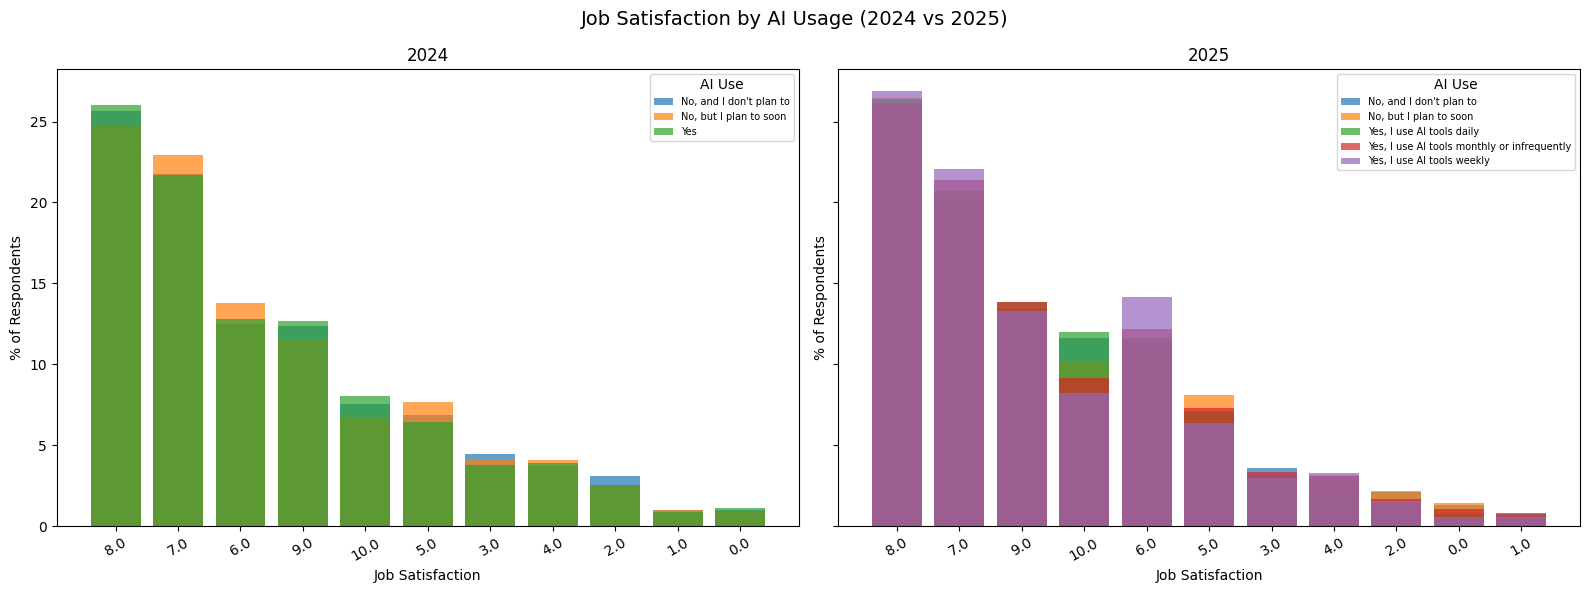

In [214]:
ai_sat = df[
    df['survey_year'].isin([2024, 2025])
    & df['ai_use'].notna()
    & df['job_sat'].notna()
].copy()

sat_by_ai = (
    ai_sat.groupby(['survey_year', 'ai_use'])['job_sat']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index(name='pct')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Job Satisfaction by AI Usage (2024 vs 2025)', fontsize=14)

for ax, year in zip(axes, [2024, 2025]):
    subset = sat_by_ai[sat_by_ai['survey_year'] == year]
    for ai_group, grp in subset.groupby('ai_use'):
        ax.bar(grp['job_sat'], grp['pct'], label=ai_group, alpha=0.7)
    ax.set_title(str(year))
    ax.set_xlabel('Job Satisfaction')
    ax.set_ylabel('% of Respondents')
    ax.legend(title='AI Use', fontsize=7)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [215]:
cols_to_drop = [
    # Never or barely available across years
    'ethnicity',
    'student',
    'undergrad_major',
    'age_first_code',
    'age_first_code_clean',
    'job_seek',
    'work_week_hrs',
    'work_week_hrs_clean',
    'learn_code_online',
    'learn_code_online_count',
    'coding_activities',
    'coding_activities_count',
    'misc_tech',
    'misc_tech_count',
    'webframe',
    'webframe_count',
    'op_sys_prof',
    'op_sys_prof_count',
    'current_tech',
    'ai_use',
    'ai_sent',
    'job_sat_num',
    'learn_code',
    'learn_code_count',
    'work_exp',
    'age_mid',
    

    'cpi_u',
    'is_comp_analysis_sample',
    'is_comp_model_core',
    'is_comp_model_tech_rich',
    'is_comp_model_ai_era',
    'is_comp_model_extended',
    'is_comp_model_sample',
    'response_id',
    'main_branch',
    'gender',
    'country'
    
    

  
]

df_clean = df.drop(columns=cols_to_drop)
print(f"Columns remaining: {len(df_clean.columns)}")
print(df_clean.columns.tolist())

Columns remaining: 46
['row_id', 'survey_year', 'country_clean', 'region', 'age', 'age_group', 'employment', 'employment_group', 'is_employed', 'is_professional', 'education', 'education_clean', 'org_size', 'org_size_clean', 'dev_type', 'industry', 'remote', 'remote_group', 'language', 'database', 'platform', 'language_count', 'database_count', 'platform_count', 'years_code', 'years_code_clean', 'years_code_pro', 'professional_experience_years', 'job_sat', 'comp', 'comp_usd_clean', 'log_comp_usd_clean', 'comp_real_2025', 'log_comp_real_2025', 'role_family_count', 'role_back_end', 'role_data_ml', 'role_desktop_enterprise', 'role_devops_cloud', 'role_front_end', 'role_full_stack', 'role_management', 'role_mobile', 'role_other', 'role_qa_testing', 'role_student_academic']


In [216]:
df_clean = df_clean[~df_clean['survey_year'].isin([2021, 2022, 2023])]
print(df_clean['survey_year'].unique())
print(f"Rows remaining: {len(df_clean):,}")

[2015 2016 2017 2018 2019 2020 2024 2025]
Rows remaining: 500,335


In [217]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

null_by_year = (
    df_clean.groupby('survey_year')
    .apply(lambda x: x.isnull().mean().mul(100).round(2))
    .T
)

display(null_by_year)

survey_year,2015,2016,2017,2018,2019,2020,2024,2025
row_id,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
country_clean,3.11,0.95,0.27,0.50,0.30,0.65,10.01,28.02
region,3.11,0.95,0.31,0.50,0.30,0.65,10.01,28.02
age,0.98,1.24,100.00,34.68,10.88,29.50,0.00,0.00
age_group,2.28,1.24,100.00,34.68,10.95,29.54,0.49,0.77
employment,18.33,11.52,0.00,3.57,1.91,0.94,0.00,1.73
employment_group,18.33,11.52,0.00,2.44,0.40,0.94,0.00,1.73
is_employed,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
is_professional,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
education,24.73,19.77,0.00,4.20,2.80,10.91,7.11,2.12


In [218]:
for year in sorted(df_clean['survey_year'].unique()):
    unique_vals = df_clean[df_clean['survey_year'] == year]['job_sat'].dropna().unique()
    print(f"\n{year}:")
    for val in unique_vals:
        print(f"  {val}")


2015:
  I'm somewhat satisfied with my job
  I'm neither satisfied nor dissatisfied with my job
  I love my job
  I'm somewhat dissatisfied with my job
  I hate my job
  Other (please specify)

2016:
  I love my job
  I don't have a job
  I'm somewhat satisfied with my job
  I'm somewhat dissatisfied with my job
  I'm neither satisfied nor dissatisfied
  Other (please specify)
  I hate my job

2017:
  9.0
  3.0
  8.0
  6.0
  7.0
  5.0
  4.0
  10.0
  2.0
  0.0
  1.0

2018:
  Extremely satisfied
  Moderately dissatisfied
  Moderately satisfied
  Neither satisfied nor dissatisfied
  Slightly satisfied
  Slightly dissatisfied
  Extremely dissatisfied

2019:
  Slightly satisfied
  Slightly dissatisfied
  Neither satisfied nor dissatisfied
  Very satisfied
  Very dissatisfied

2020:
  Slightly satisfied
  Very dissatisfied
  Slightly dissatisfied
  Very satisfied
  Neither satisfied nor dissatisfied

2024:
  8.0
  5.0
  10.0
  6.0
  9.0
  4.0
  7.0
  3.0
  2.0
  1.0
  0.0

2025:
  10.0
  9.

In [219]:
SAT_MAP = {
    # 2015
    "I love my job": 10,
    "I'm somewhat satisfied with my job": 7,
    "I'm neither satisfied nor dissatisfied with my job": 5,
    "I'm somewhat dissatisfied with my job": 3,
    "I hate my job": 0,
    "Other (please specify)": np.nan,

    # 2016 (overlaps with 2015 mostly)
    "I love my job": 10,
    "I'm somewhat satisfied with my job": 7,
    "I'm neither satisfied nor dissatisfied": 5,
    "I'm somewhat dissatisfied with my job": 3,
    "I hate my job": 0,
    "I don't have a job": np.nan,
    "Other (please specify)": np.nan,

    # 2018
    "Extremely satisfied": 10,
    "Moderately satisfied": 7,
    "Slightly satisfied": 6,
    "Neither satisfied nor dissatisfied": 5,
    "Slightly dissatisfied": 4,
    "Moderately dissatisfied": 3,
    "Extremely dissatisfied": 0,

    # 2019 & 2020
    "Very satisfied": 10,
    "Slightly satisfied": 7,
    "Neither satisfied nor dissatisfied": 5,
    "Slightly dissatisfied": 3,
    "Very dissatisfied": 0,
}

def standardize_job_sat(row):
    val = row['job_sat']
    year = row['survey_year']

    if pd.isna(val):
        return np.nan

    # 2017, 2024, 2025 are already numeric 0-10
    if year in [2017, 2024, 2025]:
        try:
            return float(val)
        except:
            return np.nan

    return SAT_MAP.get(val, np.nan)

df_clean['job_sat_std'] = df_clean.apply(standardize_job_sat, axis=1)

# Quick check
print(df_clean.groupby('survey_year')['job_sat_std'].agg(['mean', 'median', 'count']))

                 mean  median  count
survey_year                         
2015         7.344414     7.0  16004
2016         7.178618     7.0  39425
2017         6.957078     7.0  40376
2018         6.372106     7.0  69276
2019         6.618372     7.0  70988
2020         6.503231     7.0  45194
2024         6.935041     7.0  29126
2025         7.201950     8.0  26670


In [220]:
df_model = df_clean[df_clean['job_sat_std'].notna()].copy()

print(f"Rows before: {len(df_clean):,}")
print(f"Rows after:  {len(df_model):,}")
print(f"Dropped:     {len(df_clean) - len(df_model):,}")
print()
print(df_model.groupby('survey_year')['job_sat_std'].agg(['mean', 'median', 'count']))

Rows before: 500,335
Rows after:  337,059
Dropped:     163,276

                 mean  median  count
survey_year                         
2015         7.344414     7.0  16004
2016         7.178618     7.0  39425
2017         6.957078     7.0  40376
2018         6.372106     7.0  69276
2019         6.618372     7.0  70988
2020         6.503231     7.0  45194
2024         6.935041     7.0  29126
2025         7.201950     8.0  26670


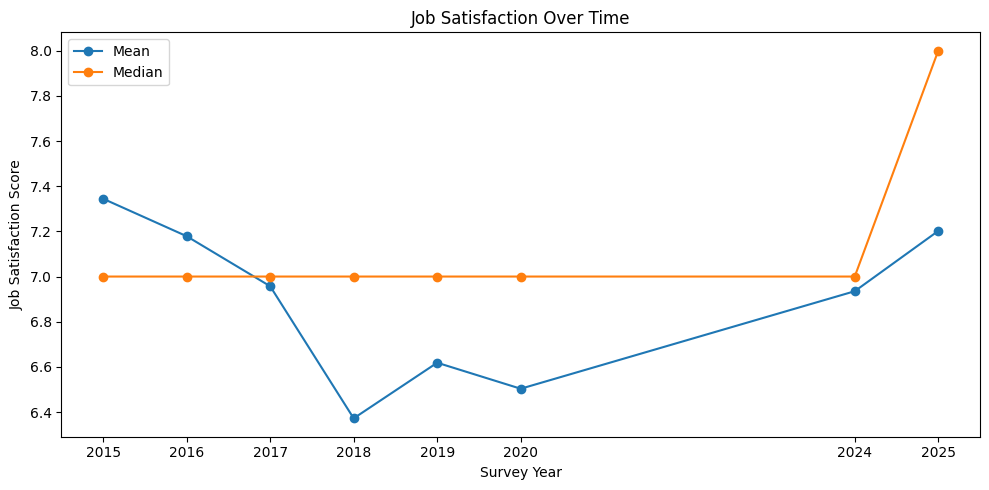

In [221]:
sat_by_year = (
    df_model.groupby('survey_year')['job_sat_std']
    .agg(['mean', 'median'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(sat_by_year['survey_year'], sat_by_year['mean'], marker='o', label='Mean')
ax.plot(sat_by_year['survey_year'], sat_by_year['median'], marker='o', label='Median')

ax.set_title('Job Satisfaction Over Time')
ax.set_xlabel('Survey Year')
ax.set_ylabel('Job Satisfaction Score')
ax.legend()
ax.set_xticks(sat_by_year['survey_year'])
plt.tight_layout()
plt.show()

In [222]:
print(df_model.groupby('survey_year').agg(
    total_rows=('job_sat', 'size'),
    non_null=('job_sat_std', lambda x: x.notna().sum()),
    null=('job_sat_std', lambda x: x.isna().sum()),
    pct_null=('job_sat_std', lambda x: round(x.isna().mean() * 100, 2)),
    mean_sat=('job_sat_std', 'mean'),
    median_sat=('job_sat_std', 'median'),
))

             total_rows  non_null  null  pct_null  mean_sat  median_sat
survey_year                                                            
2015              16004     16004     0       0.0  7.344414         7.0
2016              39425     39425     0       0.0  7.178618         7.0
2017              40376     40376     0       0.0  6.957078         7.0
2018              69276     69276     0       0.0  6.372106         7.0
2019              70988     70988     0       0.0  6.618372         7.0
2020              45194     45194     0       0.0  6.503231         7.0
2024              29126     29126     0       0.0  6.935041         7.0
2025              26670     26670     0       0.0  7.201950         8.0


In [223]:
df_clean['sat_missing'] = df_clean['job_sat_std'].isna().astype(int)
print(df_clean.groupby('survey_year')['sat_missing'].mean())
print(df_clean.groupby('employment_group')['sat_missing'].mean())
print(df_clean.groupby('region')['sat_missing'].mean())

survey_year
2015    0.386491
2016    0.296359
2017    0.214352
2018    0.299216
2019    0.201332
2020    0.298894
2024    0.554900
2025    0.457828
Name: sat_missing, dtype: float64
employment_group
Employed full-time        0.146973
Employed part-time        0.368359
Independent / contract    0.287122
Not employed              0.976526
Other                     0.459012
Student                   0.970444
Name: sat_missing, dtype: float64
region
Africa      0.437049
Americas    0.255103
Asia        0.365735
Europe      0.284995
Oceania     0.268346
Name: sat_missing, dtype: float64


mostly full-time employed professionals, 

by removing all jo_sat that are null, we can see that 97% of students and unemployed left job sat na. 
additionally almost half of people from africa left job_sat NA
modeling will underrepresent these groups 

In [224]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

null_by_year = (
    df_model.groupby('survey_year')
    .apply(lambda x: x.isnull().mean().mul(100).round(2))
    .T
)

display(null_by_year)

survey_year,2015,2016,2017,2018,2019,2020,2024,2025
row_id,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
country_clean,1.26,0.41,0.13,0.07,0.13,0.05,0.04,3.15
region,1.26,0.41,0.15,0.07,0.13,0.05,0.04,3.15
age,0.22,0.55,100.00,19.64,8.96,19.56,0.00,0.00
age_group,0.90,0.55,100.00,19.64,9.01,19.59,0.16,0.26
employment,0.22,0.11,0.00,0.00,0.47,0.28,0.00,0.00
employment_group,0.22,0.11,0.00,0.00,0.08,0.28,0.00,0.00
is_employed,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
is_professional,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
education,7.90,4.86,0.00,1.53,1.77,1.82,0.00,0.09


In [225]:
overall_null = df_model.isnull().mean().mul(100).round(2).reset_index()
overall_null.columns = ['column', 'overall_null_pct']
overall_null = overall_null.sort_values('overall_null_pct', ascending=False)

# flag columns over 50% null overall
majority_null = overall_null[overall_null['overall_null_pct'] > 50]
print("Columns with >50% nulls overall:")
print(majority_null.to_string(index=False))

Columns with >50% nulls overall:
  column  overall_null_pct
industry             56.91


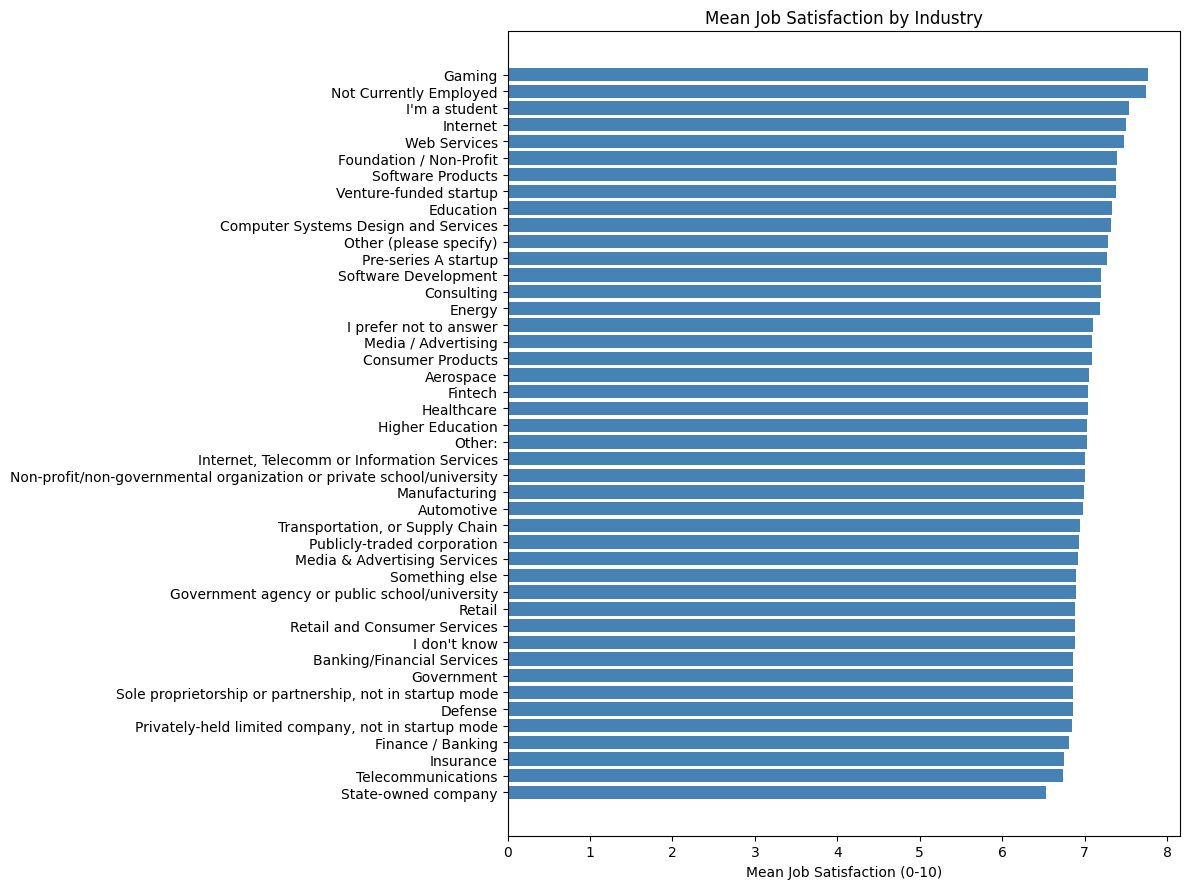

In [226]:
industry_sat = (
    df_model[df_model['industry'].notna()]
    .groupby('industry')['job_sat_std']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(industry_sat['industry'], industry_sat['job_sat_std'], color='steelblue')
ax.set_title('Mean Job Satisfaction by Industry')
ax.set_xlabel('Mean Job Satisfaction (0-10)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [227]:
df_model.info()

<class 'pandas.DataFrame'>
Index: 337059 entries, 0 to 746223
Data columns (total 47 columns):
 #   Column                         Non-Null Count   Dtype   
---  ------                         --------------   -----   
 0   row_id                         337059 non-null  int64   
 1   survey_year                    337059 non-null  int64   
 2   country_clean                  335629 non-null  string  
 3   region                         335622 non-null  string  
 4   age                            267629 non-null  string  
 5   age_group                      267354 non-null  category
 6   employment                     336522 non-null  string  
 7   employment_group               336800 non-null  string  
 8   is_employed                    337059 non-null  bool    
 9   is_professional                337059 non-null  bool    
 10  education                      330723 non-null  string  
 11  education_clean                330371 non-null  string  
 12  org_size                       2

In [228]:
# age, 

In [229]:
# --- 2015: string buckets → standard labels ---
age_2015_remap = {
    '< 20':                 'Under 18 years old',
    '20-24':                '18-24 years old',
    '25-29':                '25-34 years old',
    '30-34':                '25-34 years old',
    '35-39':                '35-44 years old',
    '40-50':                '45-54 years old',   # midpoint = 45
    '51-60':                '55-64 years old',   # midpoint = 55.5
    '> 60':                 '65 years or older',
    'Prefer not to disclose': 'Prefer not to say',
}
mask = df_model['survey_year'] == 2015
df_model.loc[mask, 'age'] = df_model.loc[mask, 'age'].map(age_2015_remap)

# --- 2016: numeric midpoints → standard labels ---
age_2016_remap = {
    16.0: 'Under 18 years old',
    22.0: '18-24 years old',
    27.0: '25-34 years old',
    32.0: '25-34 years old',
    37.0: '35-44 years old',
    44.5: '45-54 years old',
    54.5: '55-64 years old',
    65.0: '65 years or older',
}
mask = df_model['survey_year'] == 2016
df_model.loc[mask, 'age'] = df_model.loc[mask, 'age'].astype(float).map(age_2016_remap)

# --- 2018: fix spacing ---
age_2018_remap = {
    'Under 18 years old':   'Under 18 years old',
    '18 - 24 years old':    '18-24 years old',
    '25 - 34 years old':    '25-34 years old',
    '35 - 44 years old':    '35-44 years old',
    '45 - 54 years old':    '45-54 years old',
    '55 - 64 years old':    '55-64 years old',
    '65 years or older':    '65 years or older',
}
mask = df_model['survey_year'] == 2018
df_model.loc[mask, 'age'] = df_model.loc[mask, 'age'].map(age_2018_remap)

# --- 2019 & 2020: continuous numeric → standard labels ---
def numeric_to_age_group(val):
    try:
        v = float(val)
    except (TypeError, ValueError):
        return pd.NA
    if v < 10:    return pd.NA
    elif v < 18:  return 'Under 18 years old'
    elif v < 25:  return '18-24 years old'
    elif v < 35:  return '25-34 years old'
    elif v < 45:  return '35-44 years old'
    elif v < 55:  return '45-54 years old'
    elif v < 65:  return '55-64 years old'
    elif v <= 89: return '65 years or older'
    else:         return pd.NA

mask = df_model['survey_year'].isin([2019, 2020])
df_model.loc[mask, 'age'] = df_model.loc[mask, 'age'].apply(numeric_to_age_group)

# --- Rebuild age_group from age ---
age_to_group = {
    'Under 18 years old': 'Under 18 years old',
    '18-24 years old':    '18-24 years old',
    '25-34 years old':    '25-34 years old',
    '35-44 years old':    '35-44 years old',
    '45-54 years old':    '45-54 years old',
    '55-64 years old':    '55-64 years old',
    '65 years or older':  '65 years or older',
    'Prefer not to say':  'Prefer not to say',
}
df_model['age_group'] = df_model['age'].map(age_to_group)

# --- Fill NaN with 'Prefer not to say' for all years except 2017 ---
mask_not_2017 = df_model['survey_year'] != 2017
df_model.loc[mask_not_2017, 'age_group'] = df_model.loc[mask_not_2017, 'age_group'].fillna('Prefer not to say')

# Verify
for year in sorted(df_model['survey_year'].unique()):
    print(f"\n--- {year} ---")
    print(df_model[df_model['survey_year'] == year]['age_group'].value_counts())




--- 2015 ---
age_group
25-34 years old       8565
18-24 years old       3107
35-44 years old       1859
45-54 years old       1587
55-64 years old        377
Under 18 years old     314
Prefer not to say      144
65 years or older       51
Name: count, dtype: int64

--- 2016 ---
age_group
25-34 years old       20466
18-24 years old        7587
35-44 years old        4729
45-54 years old        4128
55-64 years old        1355
Under 18 years old      702
65 years or older       240
Prefer not to say       218
Name: count, dtype: int64

--- 2017 ---
Series([], Name: count, dtype: int64)

--- 2018 ---
age_group
25-34 years old       29693
Prefer not to say     13604
18-24 years old       11126
35-44 years old       10697
45-54 years old        2961
55-64 years old         779
Under 18 years old      327
65 years or older        89
Name: count, dtype: int64

--- 2019 ---
age_group
25-34 years old       34206
35-44 years old       13203
18-24 years old       11907
Prefer not to say      639

In [230]:
df_model['education_clean'] = df_model['education_clean'].fillna('Prefer not to say')


In [231]:
def clean_education_2016(value):
    if pd.isna(value):
        return 'Prefer not to say'
    parts = [p.strip() for p in str(value).split(';')]
    
    for part in parts:
        p = part.lower()
        if 'phd' in p or 'ph.d' in p or 'doctoral' in p:
            return 'Postgraduate'
    for part in parts:
        p = part.lower()
        if 'masters' in p or "master's" in p:
            return 'Postgraduate'
    for part in parts:
        p = part.lower()
        if 'b.s.' in p or 'b.a.' in p or 'bachelor' in p:
            return "Bachelor's degree"
    for part in parts:
        p = part.lower()
        if 'some college' in p or 'some university' in p:
            return 'Some college/university'
    return 'Below secondary'

mask = df_model['survey_year'] == 2016
df_model.loc[mask, 'education_clean'] = df_model.loc[mask, 'education'].apply(clean_education_2016)

print(df_model[df_model['survey_year'] == 2016]['education_clean'].value_counts())



education_clean
Bachelor's degree          13425
Below secondary            11138
Postgraduate                8054
Some college/university     4893
Prefer not to say           1915
Name: count, dtype: int64[pyarrow]


In [232]:
edu_remap = {
    # Original education_clean values
    'Primary/elementary school':    'Below secondary',
    'No formal education / other':  'Below secondary',
    'Other / ungrouped':            'Below secondary',
    'Secondary school':             'Secondary school',
    'Some college/university':      'Some college/university',
    'Associate degree':             'Some college/university',
    "Bachelor's degree":            "Bachelor's degree",
    "Master's degree":              'Postgraduate',
    'Professional degree':          'Postgraduate',
    'Doctoral degree':              'Postgraduate',
    'Prefer not to say':            'Prefer not to say',
    # Pass-throughs for values already cleaned by clean_education_2016
    'Below secondary':              'Below secondary',
    'Postgraduate':                 'Postgraduate',
}


df_model['education_clean'] = df_model['education_clean'].map(edu_remap)

# Verify
for year in sorted(df_model['survey_year'].unique()):
    print(f"\n--- {year} ---")
    print(df_model[df_model['survey_year'] == year]['education_clean'].value_counts())



--- 2015 ---
education_clean
Below secondary            6248
Bachelor's degree          4956
Postgraduate               2172
Some college/university    1363
Prefer not to say          1265
Name: count, dtype: int64

--- 2016 ---
education_clean
Bachelor's degree          13425
Below secondary            11138
Postgraduate                8054
Some college/university     4893
Prefer not to say           1915
Name: count, dtype: int64

--- 2017 ---
education_clean
Bachelor's degree          18902
Postgraduate               11990
Some college/university     6086
Secondary school            2544
Below secondary              502
Prefer not to say            352
Name: count, dtype: int64

--- 2018 ---
education_clean
Bachelor's degree          33459
Postgraduate               19467
Some college/university    10305
Secondary school            4202
Prefer not to say           1057
Below secondary              786
Name: count, dtype: int64

--- 2019 ---
education_clean
Bachelor's degree        

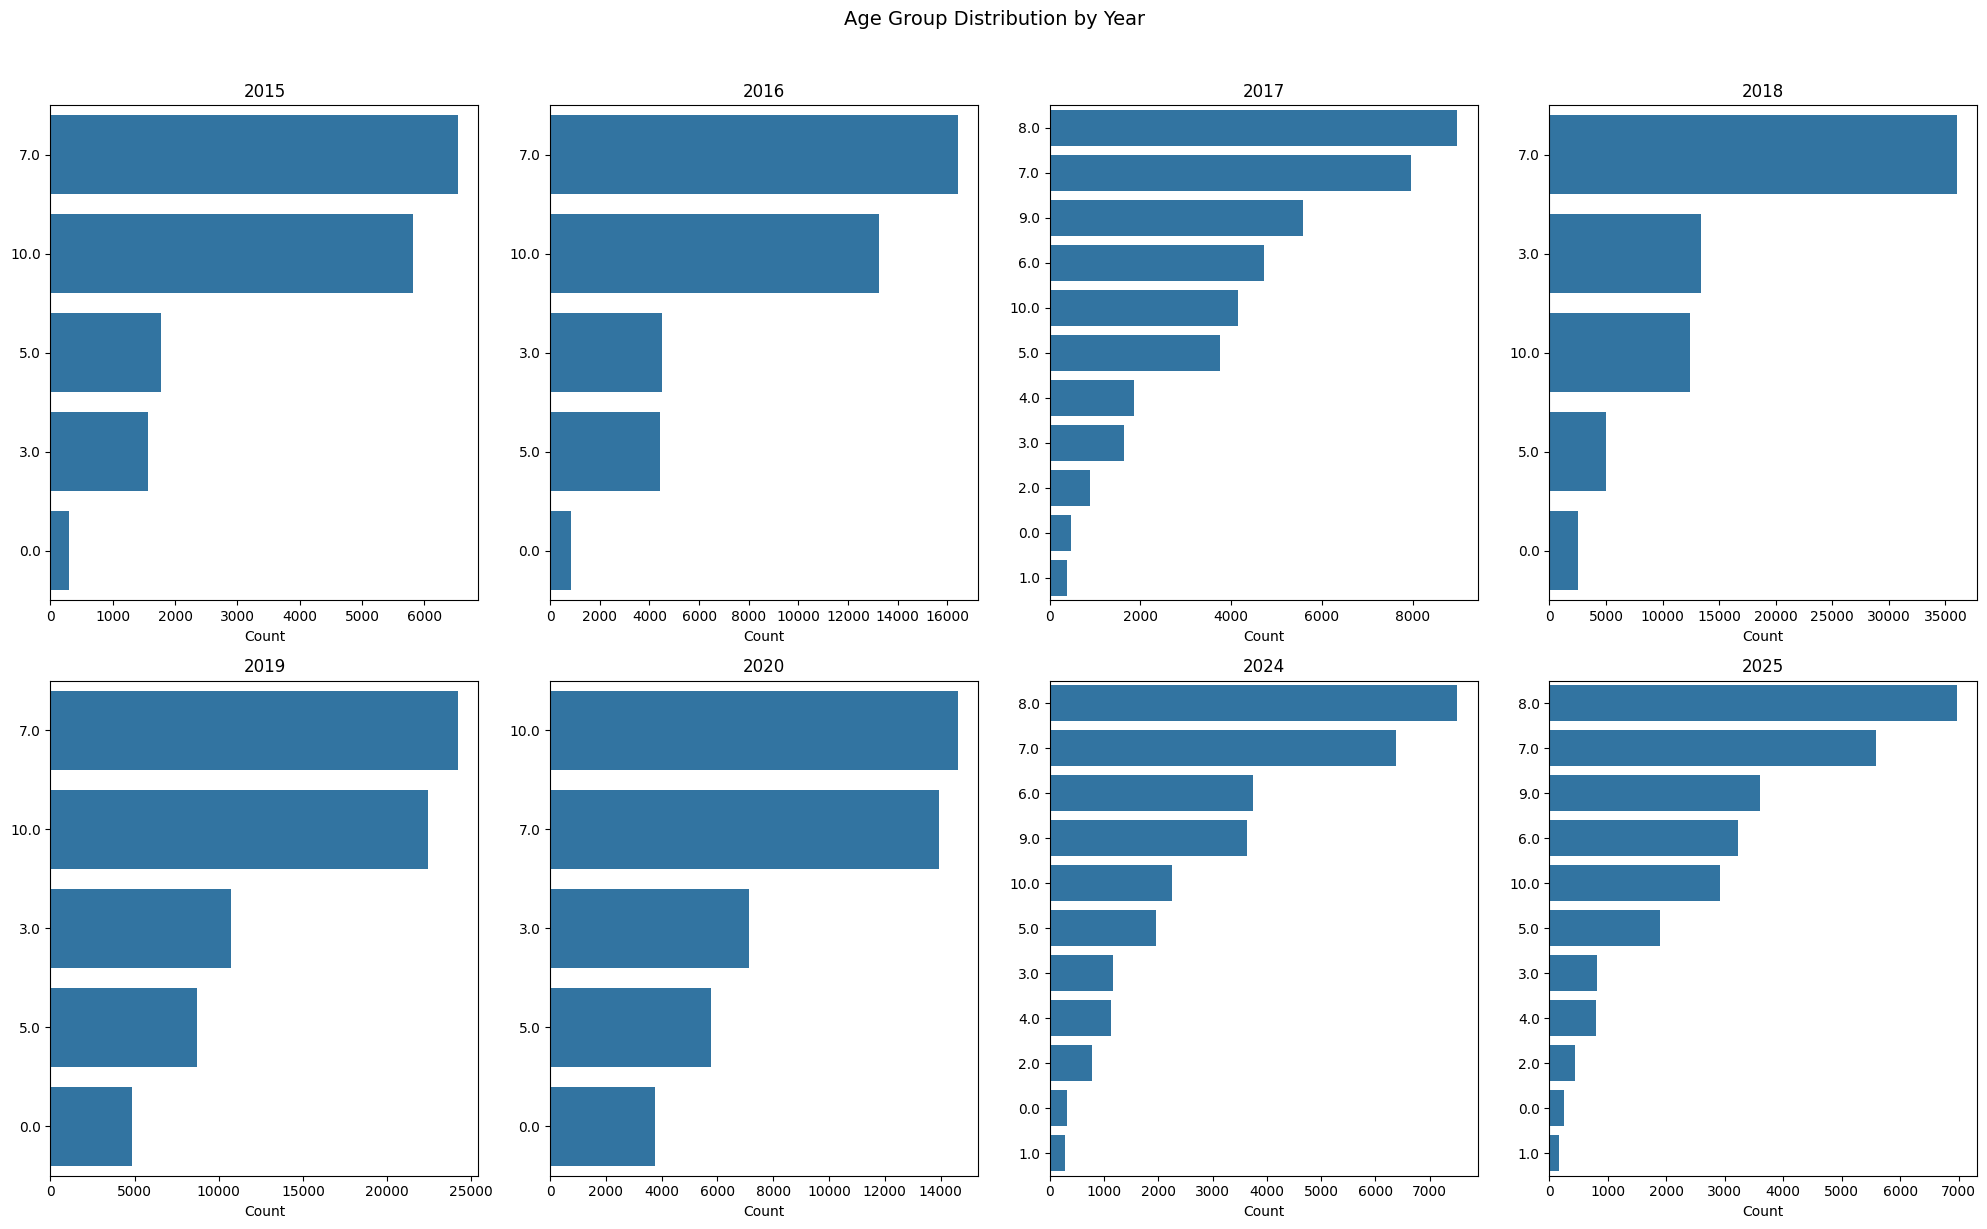

In [237]:
years = sorted(df_model['survey_year'].unique())
n = len(years)
fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(20, 12))
axes = axes.flatten()

for ax, year in zip(axes, years):
    df_year = df_model[df_model['survey_year'] == year]
    order = df_year['job_sat_std'].value_counts().index
    sns.countplot(data=df_year, y='job_sat_std', order=order, ax=ax)
    ax.set_title(str(year))
    ax.set_xlabel("Count")
    ax.set_ylabel("")

# Hide any unused subplots
for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle("Age Group Distribution by Year", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [234]:

df_model = df_model.drop(columns=['employment'])
df_model = df_model.drop(columns=['age'])
df_model = df_model.drop(columns=['education'])
df_model = df_model.drop(columns=['org_size'])

df_model = df_model.drop(columns=['remote'])
df_model = df_model.drop(columns=['language'])
df_model = df_model.drop(columns=['database'])
df_model = df_model.drop(columns=['platform'])
df_model = df_model.drop(columns=['years_code'])
df_model = df_model.drop(columns=['job_sat'])
df_model = df_model.drop(columns=['comp'])
df_model = df_model.drop(columns=['comp_usd_clean'])
df_model = df_model.drop(columns=['log_comp_usd_clean'])



education_clean	

In [235]:
df_model['employment_group'] = df_model['employment_group'].fillna('Prefer not to say')


In [245]:
df_model.info()

<class 'pandas.DataFrame'>
Index: 337059 entries, 0 to 746223
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   row_id                         337059 non-null  int64  
 1   survey_year                    337059 non-null  int64  
 2   country_clean                  335629 non-null  string 
 3   region                         335622 non-null  string 
 4   age_group                      296683 non-null  str    
 5   employment_group               337059 non-null  string 
 6   is_employed                    337059 non-null  bool   
 7   is_professional                337059 non-null  bool   
 8   education_clean                337059 non-null  str    
 9   org_size_clean                 297019 non-null  string 
 10  dev_type                       327892 non-null  string 
 11  industry                       145226 non-null  string 
 12  remote_group                   212211 non-null

In [236]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

null_by_year = (
    df_model.groupby('survey_year')
    .apply(lambda x: x.isnull().mean().mul(100).round(2))
    .T
)

display(null_by_year)

survey_year,2015,2016,2017,2018,2019,2020,2024,2025
row_id,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
country_clean,1.26,0.41,0.13,0.07,0.13,0.05,0.04,3.15
region,1.26,0.41,0.15,0.07,0.13,0.05,0.04,3.15
age_group,0.00,0.00,100.00,0.00,0.00,0.00,0.00,0.00
employment_group,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
is_employed,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
is_professional,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
education_clean,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
org_size_clean,100.00,2.56,13.72,12.87,2.92,2.16,4.71,15.57
dev_type,7.07,0.53,13.42,0.63,1.81,1.43,0.14,0.00


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014604 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 448
[LightGBM] [Info] Number of data points in the train set: 269647, number of used features: 22
[LightGBM] [Info] Start training from score 6.767785
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 6.55845
[200]	valid_0's l2: 6.55257
[300]	valid_0's l2: 6.55003
Early stopping, best iteration is:
[304]	valid_0's l2: 6.54988
RMSE: 2.559
R²:   0.049


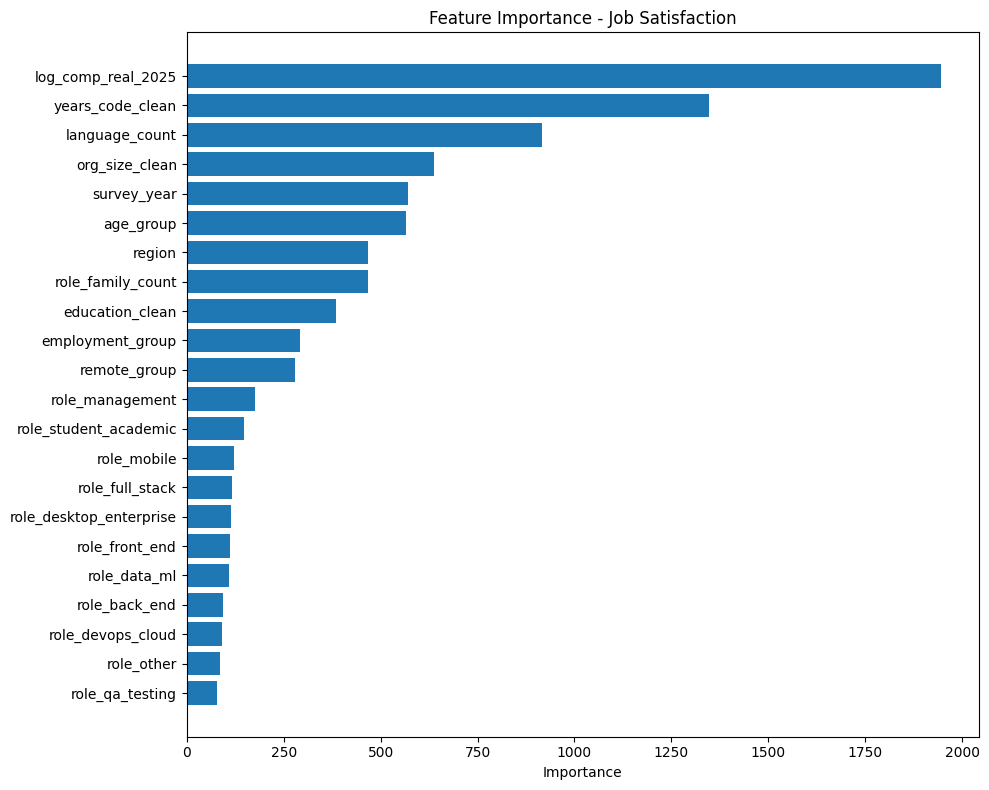

In [250]:
# --- Features ---
cat_features = [
    'survey_year', 'region', 'age_group', 'education_clean',
    'employment_group', 'org_size_clean', 'remote_group'
]
num_features = [
    'years_code_clean',
    'language_count', 'log_comp_real_2025', 'role_family_count',
    'role_back_end', 'role_data_ml', 'role_desktop_enterprise',
    'role_devops_cloud', 'role_front_end', 'role_full_stack',
    'role_management', 'role_mobile', 'role_other',
    'role_qa_testing', 'role_student_academic'
]
features = cat_features + num_features
target = 'job_sat_std'

X = df_model[features].copy()
y = df_model[target]

# Convert categoricals for LightGBM
for col in cat_features:
    X[col] = X[col].astype('category')

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Train ---
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])

# --- Evaluate ---
y_pred = model.predict(X_test)
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")
print(f"R²:   {r2_score(y_test, y_pred):.3f}")

# --- Feature importance ---
importance = (pd.DataFrame({'feature': features,
                             'importance': model.feature_importances_})
              .sort_values('importance', ascending=True))

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'], importance['importance'])
plt.title('Feature Importance - Job Satisfaction')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()



Add interaction features like is_professional × log_comp_real_2025

In [239]:
print(df_model['job_sat_std'].value_counts().sort_index())


job_sat_std
0.0      13243
1.0        814
2.0       2099
3.0      40939
4.0       3798
5.0      33261
6.0      11707
7.0     117045
8.0      23464
9.0      12797
10.0     77892
Name: count, dtype: int64


sat_group
Medium    117045
High      114153
Low       105861
Name: count, dtype: int64
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014764 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 447
[LightGBM] [Info] Number of data points in the train set: 269647, number of used features: 22
[LightGBM] [Info] Start training from score -1.082722
[LightGBM] [Info] Start training from score -1.158128
[LightGBM] [Info] Start training from score -1.057699
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 1.03881
[200]	valid_0's multi_logloss: 1.03794
[300]	valid_0's multi_logloss: 1.03782
Early stopping, best iteration is:
[268]	valid_0's multi_logloss: 1.03777
              precision    recall  f1-score   support

        High       0.47      0.58      0.52     22831
         Low       0.44      0.28    

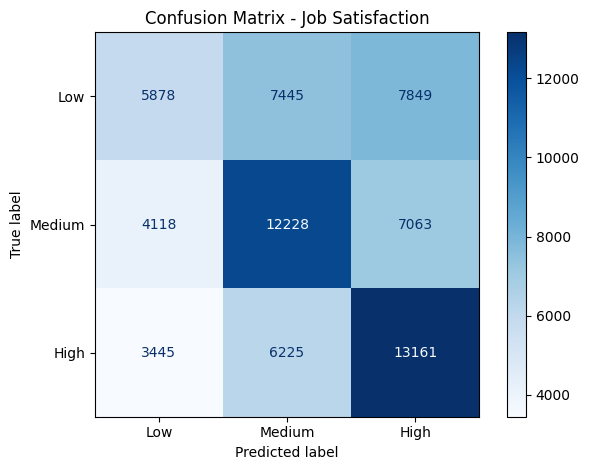

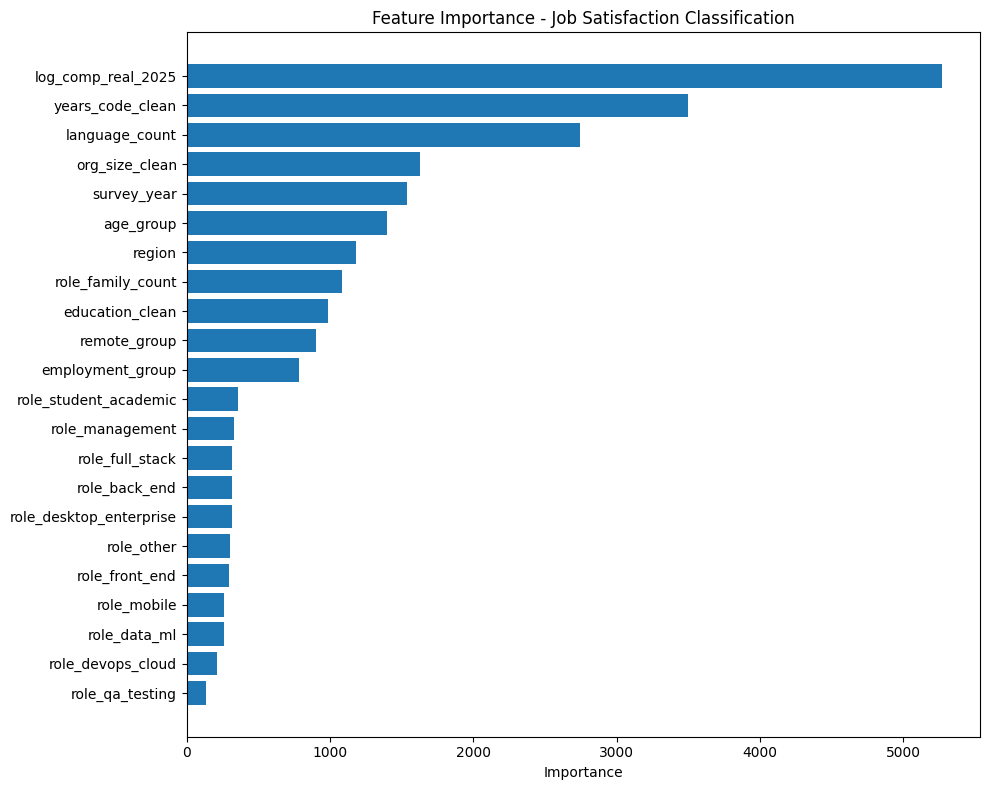

In [251]:
# --- Bin job satisfaction ---
def bin_satisfaction(x):
    if x <= 6:   return 'Low'
    elif x == 7: return 'Medium'
    else:        return 'High'

df_model['sat_group'] = df_model['job_sat_std'].apply(bin_satisfaction)
print(df_model['sat_group'].value_counts())

# --- Classification model ---

X = df_model[features].copy()
y = df_model['sat_group']

for col in cat_features:
    X[col] = X[col].astype('category')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_clf = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)
model_clf.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])

# --- Evaluate ---
y_pred = model_clf.predict(X_test)
print(classification_report(y_test, y_pred))

qwk = cohen_kappa_score(y_test, y_pred, weights='quadratic',
                        labels=['Low', 'Medium', 'High'])
print(f"Quadratic Weighted Kappa: {qwk:.3f}")

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Low', 'Medium', 'High'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Job Satisfaction')
plt.tight_layout()
plt.show()

# --- Feature importance ---
importance = (pd.DataFrame({'feature': features,
                             'importance': model_clf.feature_importances_})
              .sort_values('importance', ascending=True))

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'], importance['importance'])
plt.title('Feature Importance - Job Satisfaction Classification')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()



sat_binary
1    231198
0    105861
Name: count, dtype: int64
sat_binary
1    68.6
0    31.4
Name: proportion, dtype: float64
[LightGBM] [Info] Number of positive: 184958, number of negative: 84689
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014304 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 447
[LightGBM] [Info] Number of data points in the train set: 269647, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.675166
[200]	valid_0's binary_logloss: 0.674228
[300]	valid_0's binary_logloss: 0.673782
[400]	valid_0's binary_logloss: 0.673505
[500]	valid_0's binary_logloss: 0.673233
Did not meet early stopping. Best iteration is:
[500

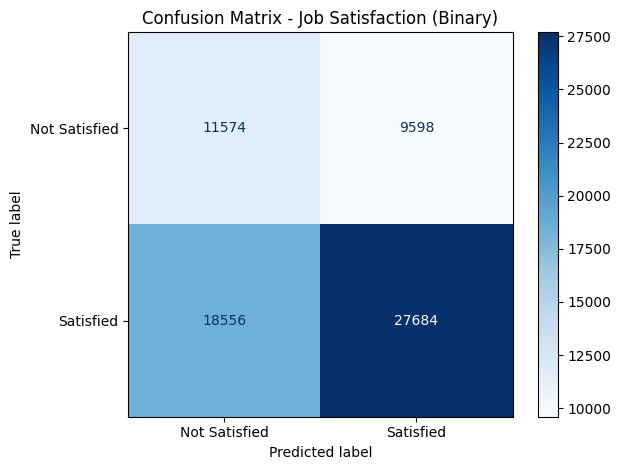

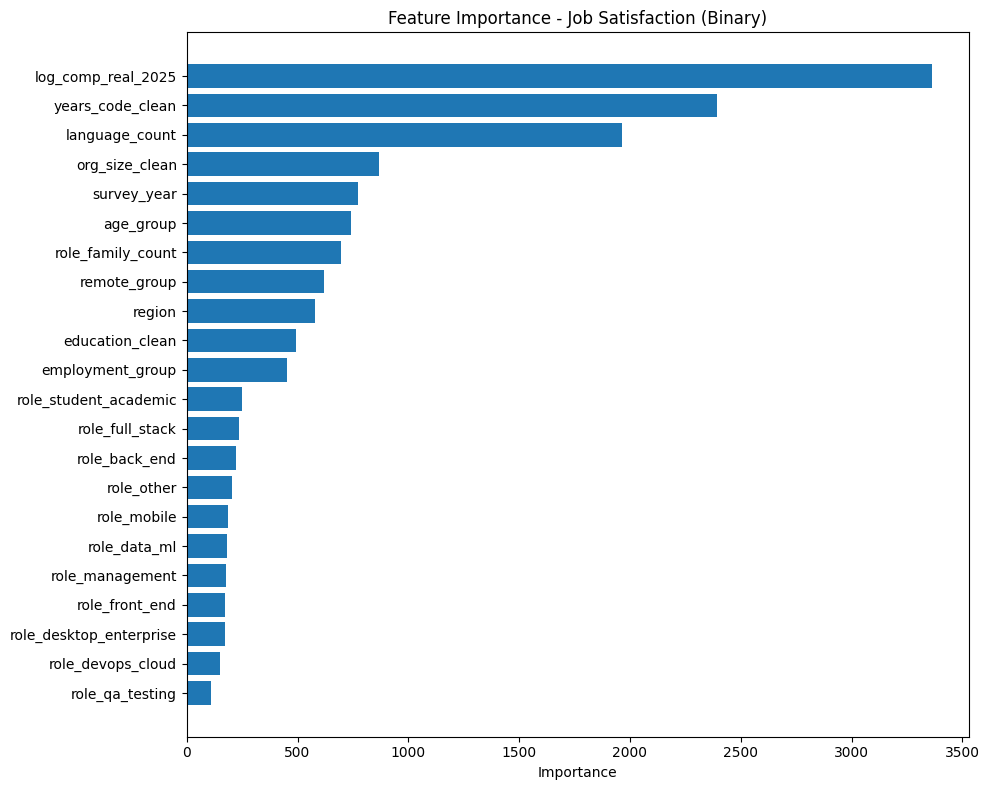

In [252]:
# --- Binary satisfaction ---
df_model['sat_binary'] = (df_model['job_sat_std'] >= 7).astype(int)
print(df_model['sat_binary'].value_counts())
print(df_model['sat_binary'].value_counts(normalize=True).mul(100).round(1))

# --- Train/test split ---
X = df_model[features].copy()
y = df_model['sat_binary']

for col in cat_features:
    X[col] = X[col].astype('category')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Train ---
model_bin = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',   # add this
    random_state=42,
    n_jobs=-1
)
model_bin.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])

# --- Evaluate ---
y_pred = model_bin.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Not Satisfied', 'Satisfied']))

qwk = cohen_kappa_score(y_test, y_pred, weights='quadratic')
print(f"Quadratic Weighted Kappa: {qwk:.3f}")

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Not Satisfied', 'Satisfied'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Job Satisfaction (Binary)')
plt.tight_layout()
plt.show()

# --- Feature importance ---
importance = (pd.DataFrame({'feature': features,
                             'importance': model_bin.feature_importances_})
              .sort_values('importance', ascending=True))

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'], importance['importance'])
plt.title('Feature Importance - Job Satisfaction (Binary)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


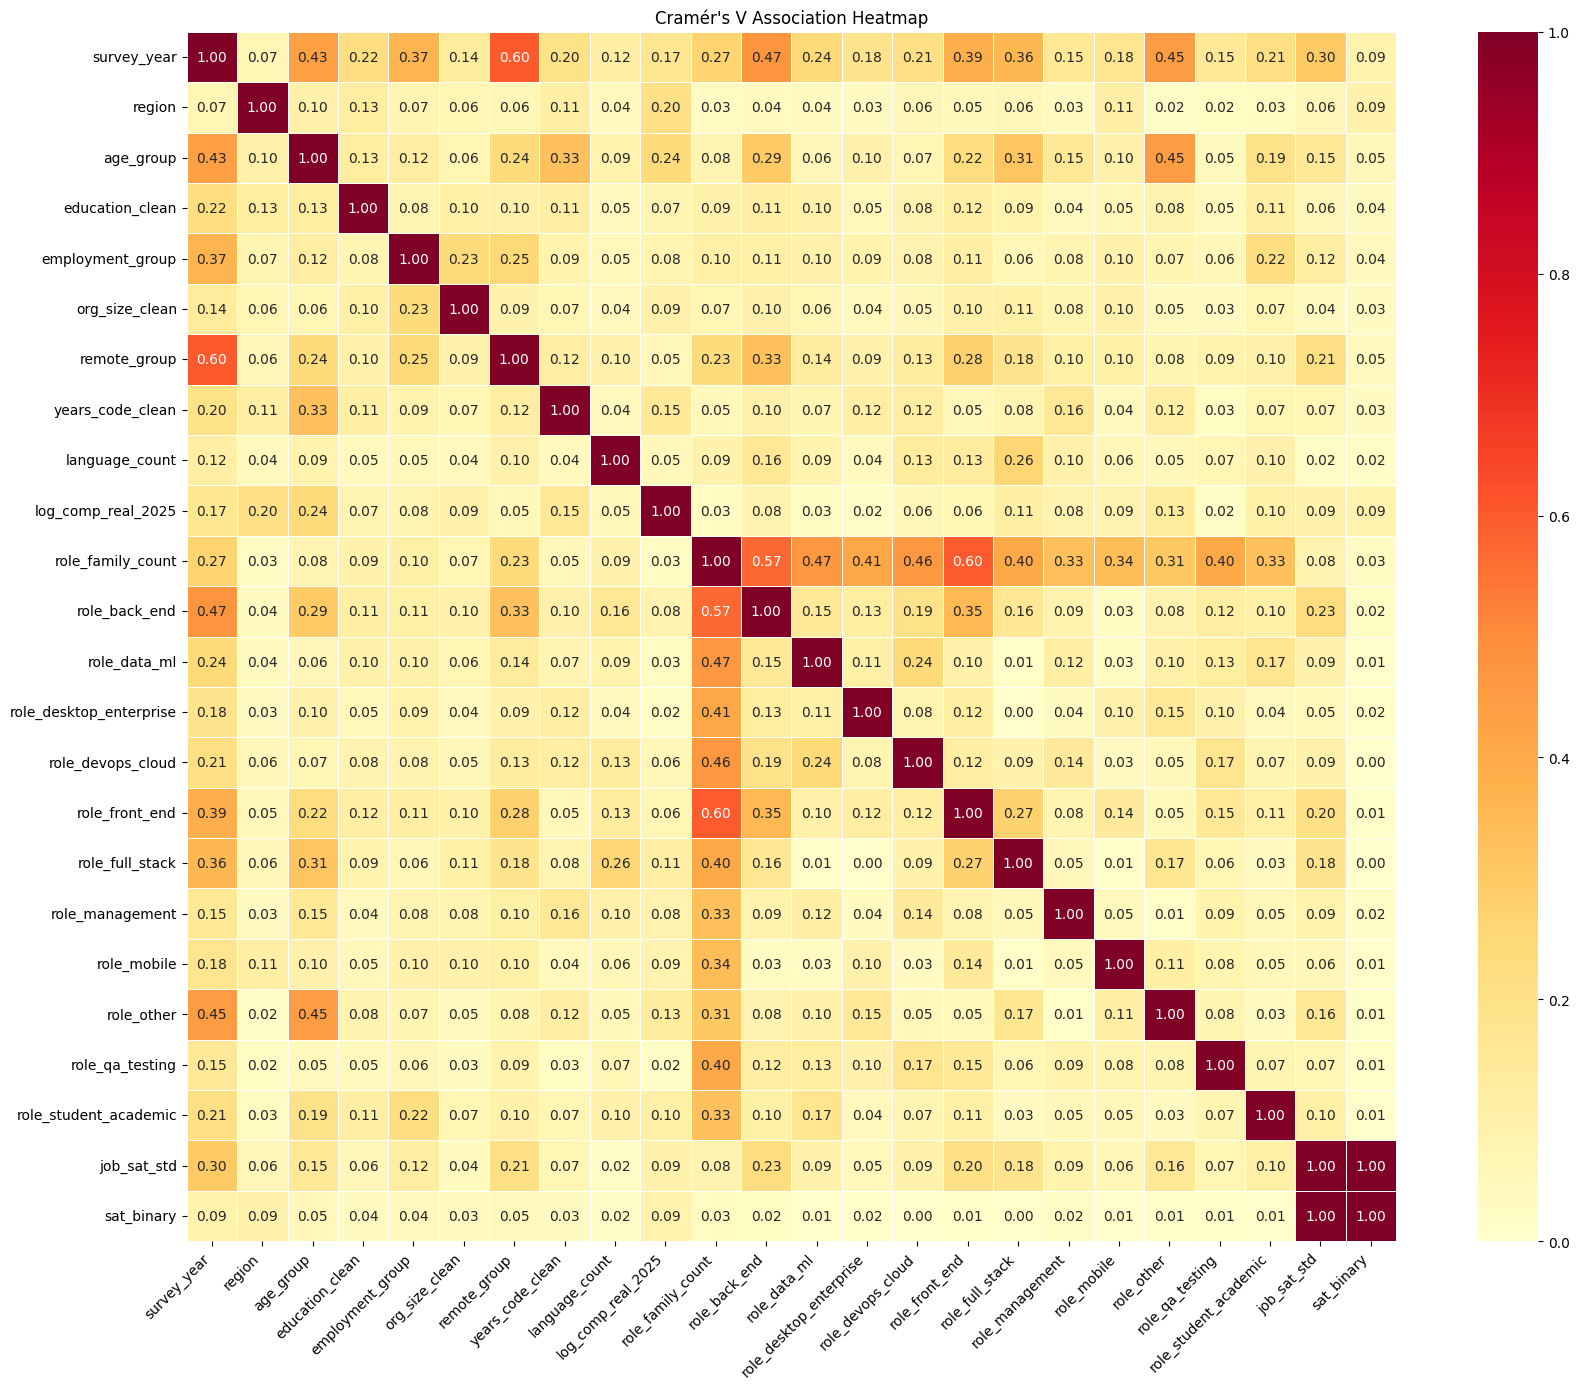

In [253]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# All columns to include
heatmap_cols = cat_features + num_features + ['job_sat_std', 'sat_binary']

# Fill nulls temporarily for crosstab (convert numerics to binned categories)
df_hm = df_model[heatmap_cols].copy()
for col in df_hm.select_dtypes(include='number').columns:
    df_hm[col] = pd.cut(df_hm[col].fillna(-1), bins=10).astype(str)
df_hm = df_hm.fillna('Missing').astype(str)

# Compute Cramér's V for all pairs
cols = df_hm.columns.tolist()
matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)

for c1, c2 in itertools.combinations(cols, 2):
    v = cramers_v(df_hm[c1], df_hm[c2])
    matrix.loc[c1, c2] = v
    matrix.loc[c2, c1] = v

for col in cols:
    matrix.loc[col, col] = 1.0

# Plot
plt.figure(figsize=(18, 14))
sns.heatmap(matrix.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, square=True,
            xticklabels=cols, yticklabels=cols)
plt.title("Cramér's V Association Heatmap")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
